# Linear Regression

In [137]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


### Data Preprocessing

In [138]:
df = pd.read_csv("linear_regression_dataset.csv")
df.head()

,AGE,FEMALE,LOS,RACE,TOTCHG,APRDRG
0,17,1,2,1.0,2660,560
1,17,0,2,1.0,1689,753
2,17,1,7,1.0,20060,930
3,17,1,1,1.0,736,758
4,17,1,1,1.0,1194,754


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     500 non-null    int64  
 1   FEMALE  500 non-null    int64  
 2   LOS     500 non-null    int64  
 3   RACE    499 non-null    float64
 4   TOTCHG  500 non-null    int64  
 5   APRDRG  500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


In [140]:
df.describe()

,AGE,FEMALE,LOS,RACE,TOTCHG,APRDRG
count,500.000000,500.000000,500.000000,499.000000,500.000000,500.000000
mean,5.086000,0.512000,2.828000,1.078156,2774.388000,616.360000
std,6.949474,0.500357,3.363487,0.514746,3888.407367,178.316044
min,0.000000,0.000000,0.000000,1.000000,532.000000,21.000000
25%,0.000000,0.000000,2.000000,1.000000,1216.250000,640.000000
50%,0.000000,1.000000,2.000000,1.000000,1536.500000,640.000000
75%,13.000000,1.000000,3.000000,1.000000,2530.250000,751.000000
max,17.000000,1.000000,41.000000,6.000000,48388.000000,952.000000


In [141]:
df.isnull().sum()

AGE       0
FEMALE    0
LOS       0
RACE      1
TOTCHG    0
APRDRG    0
dtype: int64

In [142]:
# there is 1 null value in race which we fill with mode
df['RACE'].fillna(df['RACE'].mode()[0], inplace=True)

In [143]:
df.duplicated().sum()

np.int64(27)

In [147]:
# there are 27 duplicates which we remove
df = df.drop_duplicates()
df.duplicated().sum()


np.int64(0)

In [181]:
cols = []

if "RACE" in df.columns:
    cols.append("RACE")

if "APRDRG" in df.columns:
    cols.append("APRDRG")

df = pd.get_dummies(df, columns=cols, drop_first=True)
df = df.astype(float)
#X = df.drop(columns=["TOTCHG"]).values
X = df.drop(columns=["TOTCHG"]).to_numpy(dtype=float)
y = df['TOTCHG'].values

In [182]:

np.random.seed(42)  # ensures same split every time

n = X.shape[0]

indices = np.arange(n)      # [0,1,2,...,n-1]
np.random.shuffle(indices)  # shuffle indices

split = int(0.8 * n)        # 80% train

train_idx = indices[:split]
test_idx = indices[split:]

# Apply indices
X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

In [183]:
'''
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
'''

'\nfrom sklearn.model_selection import train_test_split\n\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y,\n    test_size=0.2,\n    random_state=42\n)\n'

In [184]:
### Normalisation

In [185]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# fix division by zero
std[std == 0] = 1

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [203]:
import numpy as np

w = np.zeros(X_train.shape[1])
b = 0

lr = 0.03
epochs = 1000

In [204]:
def compute_cost(X, y, w, b):
    m = len(y)
    preds = X @ w + b
    return (1/m) * np.sum((preds - y)**2)

In [205]:
def gradient_descent(X, y, w, b, lr):
    m = len(y)
    preds = X @ w + b
    
    dw = (2/m) * (X.T @ (preds - y))
    db = (2/m) * np.sum(preds - y)
    
    w -= lr * dw
    b -= lr * db
    
    return w, b

In [206]:
train_costs = []
test_costs = []

for epoch in range(epochs):
    w, b = gradient_descent(X_train, y_train, w, b, lr)
    
    train_cost = compute_cost(X_train, y_train, w, b)
    test_cost = compute_cost(X_test, y_test, w, b)
    
    train_costs.append(train_cost)
    test_costs.append(test_cost)
    
    print(f"Epoch {epoch+1}: Train={train_cost:.4f}, Test={test_cost:.4f}")

Epoch 1: Train=19382248.9456, Test=26988376.7046
Epoch 2: Train=16883167.9471, Test=23835624.6706
Epoch 3: Train=14745163.5296, Test=21157036.9810
Epoch 4: Train=12910937.4225, Test=18874371.6803
Epoch 5: Train=11333260.9713, Test=16923393.7466
Epoch 6: Train=9973023.3482, Test=15251180.2139
Epoch 7: Train=8797691.0654, Test=13813976.5861
Epoch 8: Train=7780086.2227, Test=12575485.8066
Epoch 9: Train=6897412.8193, Test=11505497.7616
Epoch 10: Train=6130476.9790, Test=10578787.7651
Epoch 11: Train=5463059.4390, Test=9774228.2153
Epoch 12: Train=4881408.1414, Test=9074069.7476
Epoch 13: Train=4373825.9946, Test=8463357.6011
Epoch 14: Train=3930334.3969, Test=7929456.1985
Epoch 15: Train=3542397.3487, Test=7461660.6108
Epoch 16: Train=3202694.2442, Test=7050878.0048
Epoch 17: Train=2904931.9526, Test=6689365.6391
Epoch 18: Train=2643688.7516, Test=6370514.6937
Epoch 19: Train=2414284.2021, Test=6088671.3686
Epoch 20: Train=2212670.2394, Test=5838988.3770
Epoch 21: Train=2035339.6917, Test

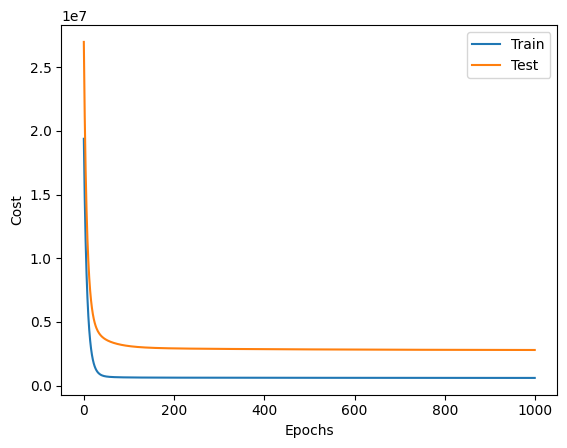

In [207]:
import matplotlib.pyplot as plt

plt.plot(train_costs, label="Train")
plt.plot(test_costs, label="Test")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [208]:
import numpy as np

def r2_score(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_residual = np.sum((y_true - y_pred)**2)
    r2 = 1 - (ss_residual / ss_total)
    return r2

In [209]:
train_pred = X_train @ w + b
test_pred = X_test @ w + b

In [211]:
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Train R2:", round(train_r2, 4))
print("Test R2:", round(test_r2, 4))

Train R2: 0.9584
Test R2: 0.8657
